# IQM QEC Pipeline Showcase

This notebook demonstrates the main pipeline results we have been building:

1. Clean distance-3 rotated surface code on the best IQM Emerald placement using `iqm_qec_pipeline`.
2. Distance-3 Snakes-and-Ladders deformed surface codes with a deliberately faulty coupler using `snl_iqm_pipeline`.
3. Synthetic distance-5 Snakes-and-Ladders code with a central data-qubit defect, using calibration-derived noise.

Each experiment produces:

- a logical error probability sweep over rounds,
- a fitted logical error rate per round,
- a linear-scale and log-scale plot,
- a lattice/stabilizer visualization.

Set `RUN_MODE = "hardware"` only when you want to submit hardware jobs. In synthetic mode, we run the same Stim/Qiskit/decoder pipeline, but replace the real IQM measurement results with Stim samples from an Emerald calibration-derived noise model. 

In [90]:
import importlib
import os
import subprocess
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

SNL_REPO_URL = "https://github.com/amazon-science/snakes_and_ladders_adapting_the_surface_code_to_defects.git"
SNL_REPO_DIR = Path("snakes_and_ladders_adapting_the_surface_code_to_defects")
if not (SNL_REPO_DIR / "defects_module").exists():
    print("Downloading Snakes-and-Ladders dependency...")
    subprocess.run(["git", "clone", "--depth", "1", SNL_REPO_URL, str(SNL_REPO_DIR)], check=True)
os.environ.setdefault("SNL_REPO", str(SNL_REPO_DIR.resolve()))
if str(SNL_REPO_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SNL_REPO_DIR.resolve()))

import iqm_qec_pipeline as iqm
import snl_iqm_pipeline as snl
import helper_visualisation as hv

from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.base import PauliT, Pos, SuperStabilizer  # noqa: E402
from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.code_library import RotatedSurfaceCode  # noqa: E402
from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.defects import DefectiveSurfaceCode, Heuristics  # noqa: E402
from snakes_and_ladders_adapting_the_surface_code_to_defects.defects_module.utils import memory_program, standard_noise  # noqa: E402

iqm = importlib.reload(iqm)
snl = importlib.reload(snl)
hv = importlib.reload(hv)

# Global run controls. Use hardware only when you are ready to submit real jobs.
RUN_MODE = "synthetic"      # "synthetic" or "hardware"
API_URL = "https://resonance.iqm.tech/"
TOKEN = "QAgmAe1q34cPweXxUtCu3RuMUIAVZrUhiPfqDCyChu0BnqZwjTJ2wpu6esoxHuYM"    # set your IQM token here
SHOTS = 5_000
ROUND_VALUES = (1, 3, 5, 10)
BASIS = "Z"
DECODER_NOISE = "average"     # "exact" or "average"

CAL = iqm.refresh_calibration_if_needed(
    api_url=API_URL,
    token=TOKEN,
    quantum_computer="emerald",
)
print("Using calibration:", CAL)

Loaded today's calibration data: calibration_data/2026-06-08T06_12_52.097243Z.json
Using calibration: calibration_data/2026-06-08T06_12_52.097243Z.json


## 1. Distance 3 Surface Code on IQM Emerald

First let us do a basic run of d=3 surface code using the `iqm_qec_pipeline`. It optimizes the d=3 layout on the IQM Emerald lattice, runs the round sweep, plots the fitted logical error rate, and visualizes the stabilizer-measurement couplings. 

The swap count is included as part of the data. We get swap_count from the transpiled Qiskit circuit, after mapping the Stim/Qiskit circuit onto the IQM backend. Since we optimized the lattice, we get `'swap_count': 0`, which you can check in the `clean_d3["summary"]`.  

Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

rounds=1 | corrected_prob=0.1894 | uncorrected_prob=0.263 | swap_count=0 | skipped_ops=0 | job=019ea6c5-c3f2-7ea1-8c6c-632f2c14cd1e


Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

rounds=3 | corrected_prob=0.4344 | uncorrected_prob=0.4674 | swap_count=0 | skipped_ops=0 | job=019ea6c6-6fb0-7f23-9595-a66b18d67966


Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

rounds=5 | corrected_prob=0.4912 | uncorrected_prob=0.49 | swap_count=0 | skipped_ops=0 | job=019ea6c7-5d77-7ef1-8616-39331db39b84


Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

rounds=10 | corrected_prob=0.5036 | uncorrected_prob=0.4978 | swap_count=0 | skipped_ops=0 | job=019ea6c8-4532-7713-80dd-56bb2c9e601a


{'distance': 3,
 'round_values': [1, 3, 5, 10],
 'shots': 5000,
 'run_mode': 'hardware',
 'decoder_noise': 'average',
 'logical_error_rate': 0.21383064149320746,
 'uncorrected_logical_error_rate': 0.27069081207406037,
 'mapping': {1: 16,
  2: 8,
  3: 9,
  5: 4,
  8: 25,
  9: 17,
  10: 18,
  11: 10,
  12: 11,
  13: 5,
  14: 33,
  15: 34,
  16: 26,
  17: 27,
  18: 19,
  19: 20,
  25: 28},
 'layout_diagnostics': {'mapping_source': 'geometry',
  'score': -0.5004080959993421,
  'usable_twoq_gate_count': 24,
  'missing_twoq_gate_count': 0,
  'min_used_cz_fidelity': 0.9774628909076772,
  'candidate_count': 93,
  'exact_graph_error': None},
 'synthetic_defect_qubits': [],
 'synthetic_defect_probability': None,
 'swap_count': 0,
 'skipped_hardware_operation_count': 0}

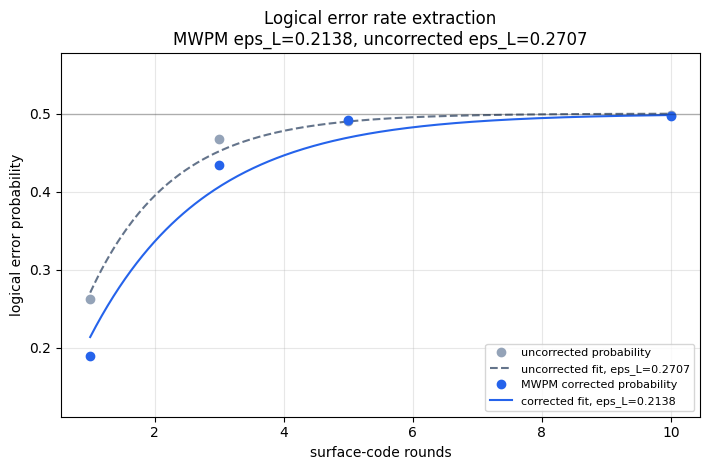

In [ ]:
ROUND_VALUES = (1, 3, 5, 8, 10, 15, 20)
clean_d3 = iqm.run_round_sweep(
    distance=3,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    run_mode="hardware",
    decoder_noise="average",
    cal=CAL,
    token=TOKEN,
    api_url=API_URL,
    optimize_layout=True,
    refresh_calibration=False,
    show_error_plot=True,
)

clean_d3["summary"] # as part of the summary you can see that number of swap counts is 0.


Here you can see the location on the lattice our layout optimizer found. The optimizer grades each subsection of the lattice by the score: 

$$
\text{score}
=
\sum_{q \in Q_{\text{used}}}
\left(
\log(F^{(1)}_q)
+
\log(1 - M_q)
\right)
+
\sum_{e \in E_{\text{used}}}
n_e \log(F^{(\mathrm{CZ})}_e)
$$


logarithmic scale is used to penalize very bad couplers and qubit comparatively more. 

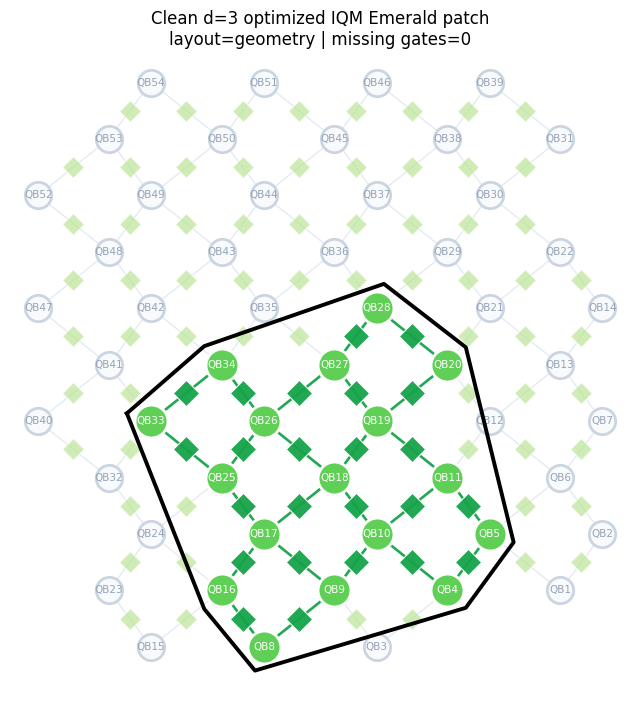

In [80]:
clean_d3_patch_fig = hv.plot_used_emerald_patch(
    clean_d3["results"][0],
    title="Clean d=3 optimized IQM Emerald patch",
)

Below, you can see the sequence of gates applied on hardware. It is comparable to the stim `circuit.diagram('timeslice-svg')` visualisation, but for IQM emerald.

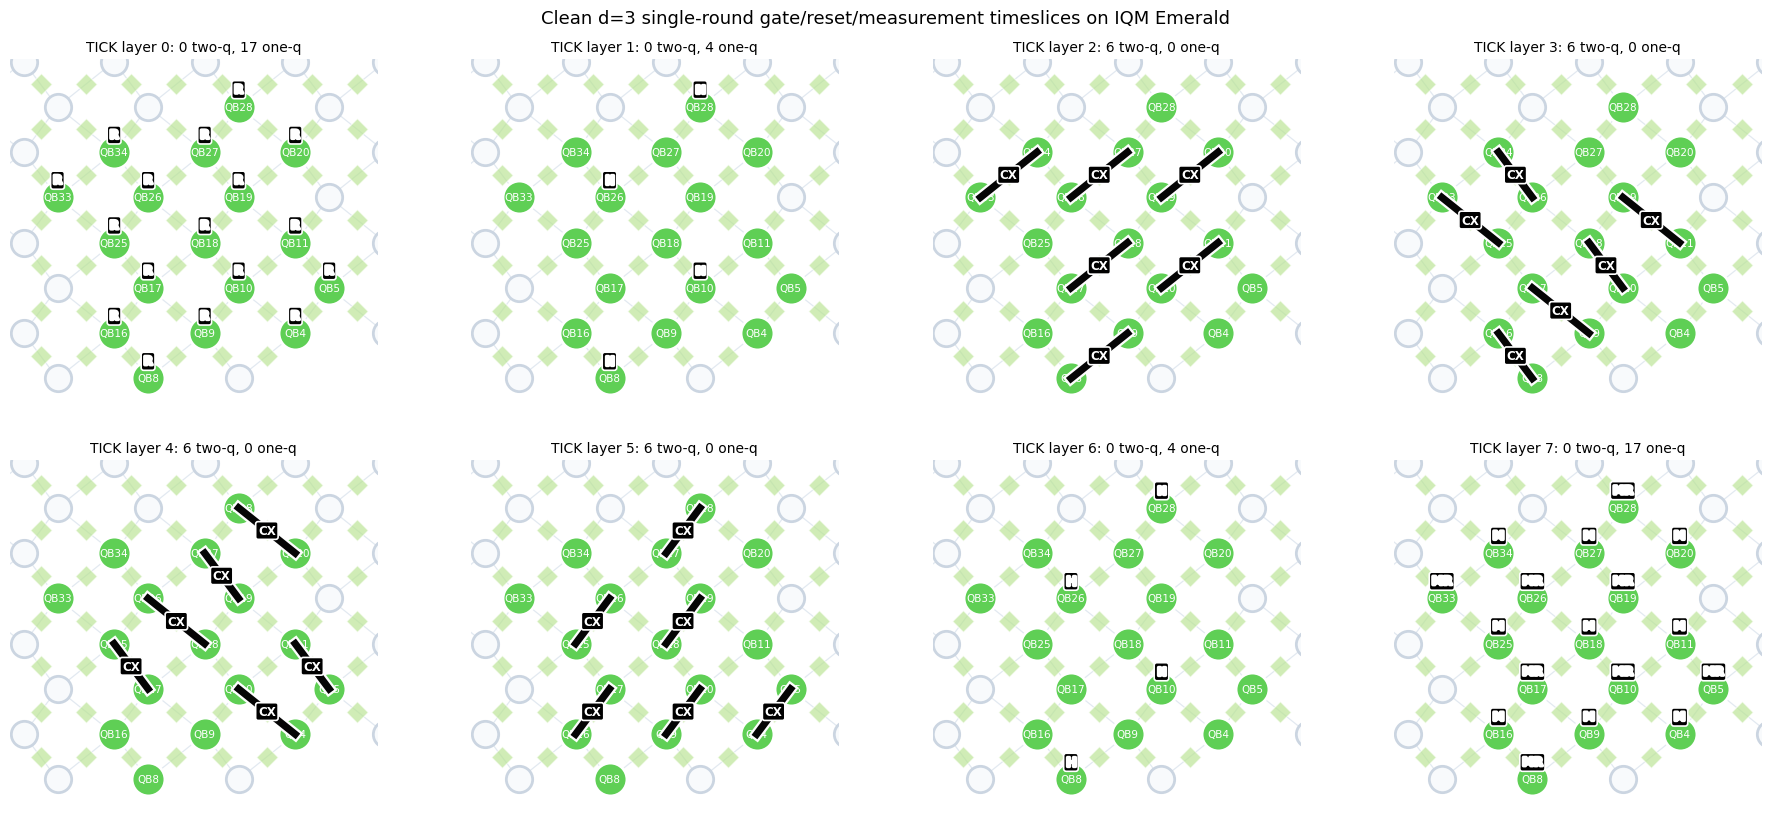

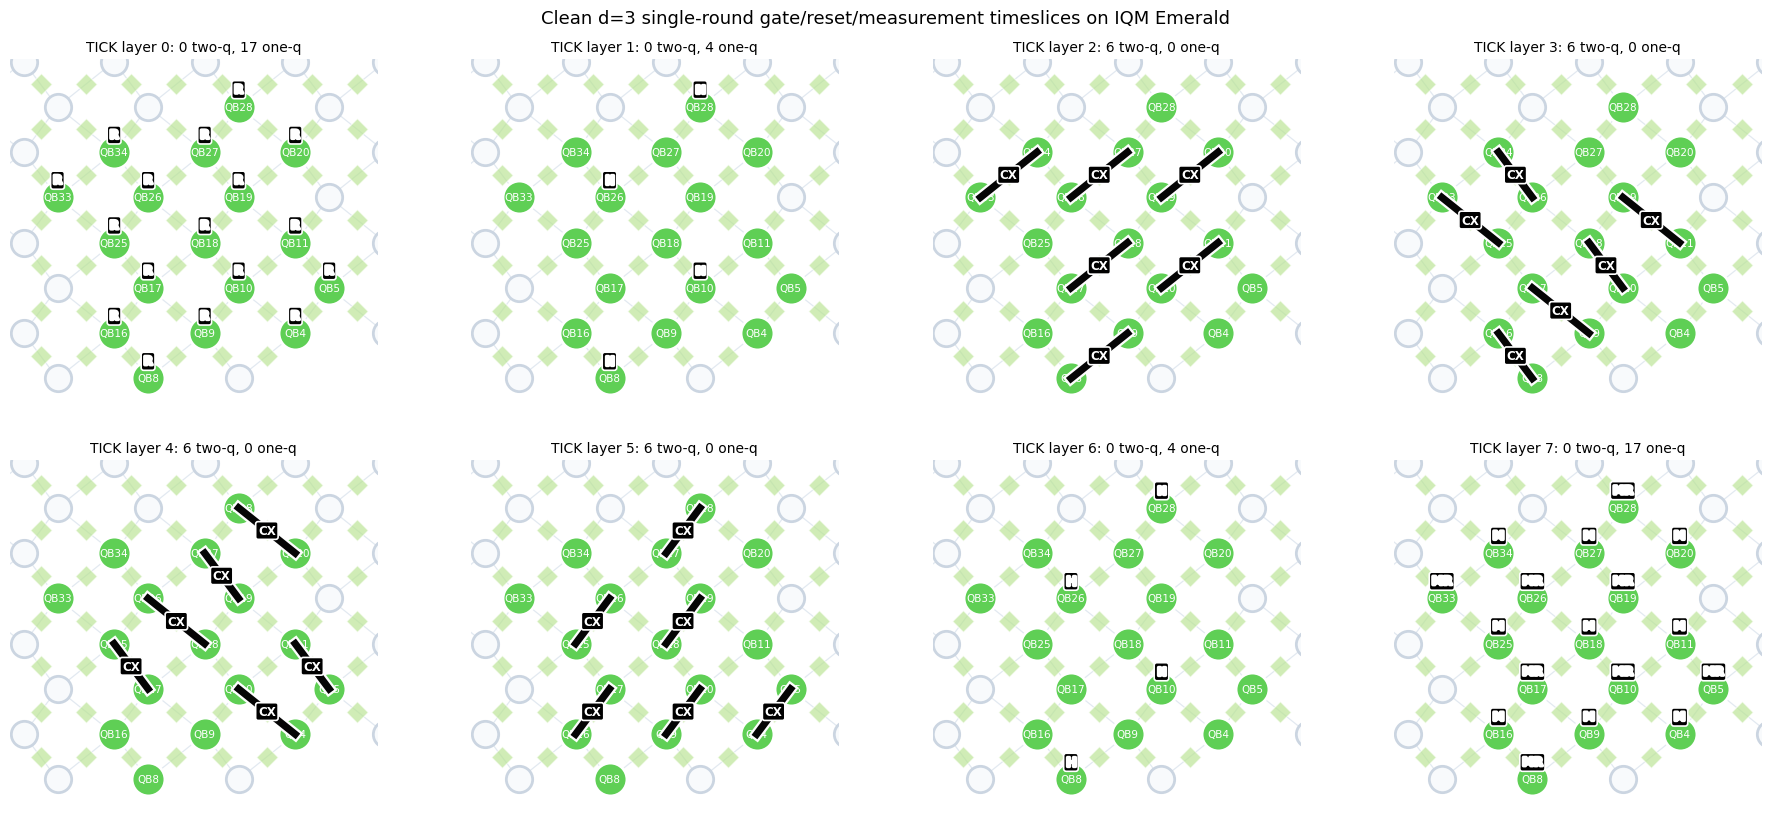

In [81]:
clean_d3_timeslice_fig = hv.plot_iqm_timeslice_layers(
    clean_d3["results"][0],
    max_layers=8,
    cols=4,
    title="Clean d=3 single-round gate/reset/measurement timeslices on IQM Emerald",
    zoom_to_used=True,
)
clean_d3_timeslice_fig


# 2. Logical error rate comparison simulated on larger lattices

Let us see how our QEC pipeline scales with distance. Due to finite size of Emerald, let us use synthetic measuement data - this works the exact same way as on hardware but instead of getting measurement results from Emerald we are using the noise model of Emerald to sample measurement outcomes that would be comparable to Emerald. Synthetic mode is also useful for making sure the pipeline is correct. However, more interstingly, with our `synthetic` mode, we can push the distances we can reach to essentially simulate a larger quantum computer. 

rounds=1 | corrected_prob=0.0335 | uncorrected_prob=0.12 | skipped_ops=0 | job=None
rounds=2 | corrected_prob=0.0325 | uncorrected_prob=0.1605 | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.0585 | uncorrected_prob=0.1865 | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.0905 | uncorrected_prob=0.237 | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.1245 | uncorrected_prob=0.3315 | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.154 | uncorrected_prob=0.3365 | skipped_ops=0 | job=None
rounds=15 | corrected_prob=0.224 | uncorrected_prob=0.404 | skipped_ops=0 | job=None
rounds=20 | corrected_prob=0.2485 | uncorrected_prob=0.4465 | skipped_ops=0 | job=None
rounds=30 | corrected_prob=0.3175 | uncorrected_prob=0.484 | skipped_ops=0 | job=None
rounds=40 | corrected_prob=0.397 | uncorrected_prob=0.4805 | skipped_ops=0 | job=None
rounds=50 | corrected_prob=0.3855 | uncorrected_prob=0.504 | skipped_ops=0 | job=None
rounds=1 | corrected_prob=0.0255 | uncorrected_prob=0.216

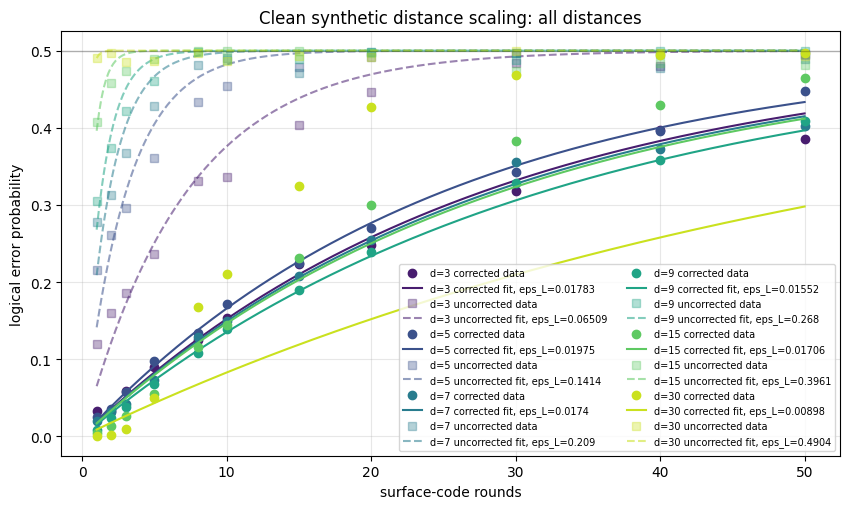

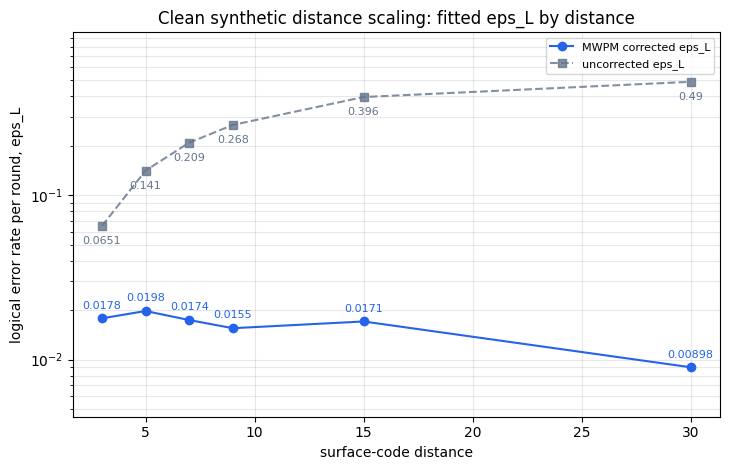

In [67]:

DISTANCES = (3, 5, 7, 9, 15, 30)
SCALING_ROUNDS = (1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 50)
SCALING_SHOTS = 2_000          # increase for smoother final plots

clean_distance_results = {}
for distance in DISTANCES:
    clean_distance_results[distance] = iqm.run_round_sweep(
        distance=distance,
        round_values=SCALING_ROUNDS,
        shots=SCALING_SHOTS,
        basis="Z",
        cal=CAL,
        run_mode="synthetic",
        decoder_noise="average",
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=False,
        show_error_plot=False,
    )



def print_ler_table(title, results_by_label):
    print("\n" + title)
    print("-" * len(title))
    for label, out in results_by_label.items():
        s = out["summary"]
        # print(
        #     f"{label}: corrected eps_L={s['logical_error_rate']:.5g}, "
        #     f"uncorrected eps_L={s['uncorrected_logical_error_rate']:.5g}"
        # )


def plot_distance_ler(clean_results, defect_results):
    """Plot fitted logical error rate per round vs distance on linear scale only."""
    distances = np.array(sorted(clean_results), dtype=float)
    clean_corr = np.array([clean_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
    clean_unc = np.array([clean_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])
    defect_corr = np.array([defect_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
    defect_unc = np.array([defect_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ax.plot(distances, clean_corr, "o-", label="clean, MWPM corrected")
    ax.plot(distances, clean_unc, "o--", label="clean, uncorrected")
    ax.plot(distances, defect_corr, "s-", label="SnL one defect, MWPM corrected")
    ax.plot(distances, defect_unc, "s--", label="SnL one defect, uncorrected")
    for xs, ys in [(distances, clean_corr), (distances, clean_unc), (distances, defect_corr), (distances, defect_unc)]:
        for x0, y0 in zip(xs, ys):
            ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
    ax.set_xlabel("surface-code distance")
    ax.set_ylabel("logical error rate per round")
    ax.set_title("Distance scaling with calibration-derived noise")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


print_ler_table("Clean synthetic distance scaling", {str(k): v for k, v in clean_distance_results.items()})
fig, ax = plt.subplots(figsize=(8.6, 5.2))
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(clean_distance_results)))
for color, distance in zip(colors, sorted(clean_distance_results)):
    out = clean_distance_results[distance]
    fit = out["fit"]
    rounds = np.asarray(fit["rounds"], dtype=float)
    xs = np.linspace(rounds.min(), rounds.max(), 300)
    corrected_eps = fit["corrected_fit"]["epsilon_l"]
    uncorrected_eps = fit["uncorrected_fit"]["epsilon_l"]

    ax.plot(
        rounds,
        fit["corrected_fit_prob"],
        "o",
        color=color,
        label=f"d={distance} corrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, corrected_eps),
        "-",
        color=color,
        label=f"d={distance} corrected fit, eps_L={corrected_eps:.4g}",
    )
    ax.plot(
        rounds,
        fit["uncorrected_fit_prob"],
        "s",
        color=color,
        alpha=0.35,
        label=f"d={distance} uncorrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, uncorrected_eps),
        "--",
        color=color,
        alpha=0.55,
        label=f"d={distance} uncorrected fit, eps_L={uncorrected_eps:.4g}",
    )

ax.axhline(0.5, color="black", lw=1, alpha=0.25)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title("Clean synthetic distance scaling: all distances")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=7, ncols=2)
fig.tight_layout()
plt.show()

# Log-scale distance trend: fitted logical error rate per round vs code distance.
distances = np.array(sorted(clean_distance_results), dtype=float)
corrected_ler = np.array([clean_distance_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
uncorrected_ler = np.array([clean_distance_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(distances, corrected_ler, "o-", color="#2563eb", label="MWPM corrected eps_L")
ax.plot(distances, uncorrected_ler, "s--", color="#64748b", alpha=0.8, label="uncorrected eps_L")
for x0, y0 in zip(distances, corrected_ler):
    ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color="#2563eb")
for x0, y0 in zip(distances, uncorrected_ler):
    ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, -13), ha="center", fontsize=8, color="#64748b")
positive = np.concatenate([corrected_ler[corrected_ler > 0], uncorrected_ler[uncorrected_ler > 0]])
if len(positive):
    ax.set_yscale("log")
    ax.set_ylim(max(positive.min() / 2, 1e-8), min(positive.max() * 2, 1.0))
ax.set_xlabel("surface-code distance")
ax.set_ylabel("logical error rate per round, eps_L")
ax.set_title("Clean synthetic distance scaling: fitted eps_L by distance")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()



# 3. Decoder comparison

We have the option to decode with two different detector error models; `exact` and `average`. `Exact` uses exact noise model for each qubit/coupler that was computed based on calibration data, and `average` uses the average noise from qubits and couplers. Let us compare their performance by decoding on the same hardware data. 

In [ ]:
SCALING_ROUNDS = (1, 3, 5, 10, 15)
SHOTS = 5000

d3_decoder_comparison = {}
for decoder_noise in ("average", "exact"):
    d3_decoder_comparison[decoder_noise] = iqm.run_round_sweep(
        distance=3,
        round_values=SCALING_ROUNDS,
        shots=SHOTS,
        basis=BASIS,
        cal=CAL,
        token=TOKEN,
        api_url=API_URL,
        run_mode="hardware",
        decoder_noise=decoder_noise,
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=True,
        show_error_plot=False,
    )

rounds=1 | corrected_prob=0.2076 | uncorrected_prob=0.2798 | swap_count=0 | skipped_ops=0 | job=019ea72f-d6e2-7162-9bbe-e7328d5d0f62
rounds=3 | corrected_prob=0.413 | uncorrected_prob=0.4678 | swap_count=0 | skipped_ops=0 | job=019ea730-05a1-7a63-945f-97ca71550aed
rounds=5 | corrected_prob=0.4724 | uncorrected_prob=0.495 | swap_count=0 | skipped_ops=0 | job=019ea730-3855-70f2-aedc-94fa7b025567
rounds=10 | corrected_prob=0.4978 | uncorrected_prob=0.508 | swap_count=0 | skipped_ops=0 | job=019ea730-69e2-7011-ab25-d6e427cb0ea9
rounds=15 | corrected_prob=0.5028 | uncorrected_prob=0.5042 | swap_count=0 | skipped_ops=0 | job=019ea730-8f0b-74c3-86f7-5ed972b5a361
rounds=1 | corrected_prob=0.1962 | uncorrected_prob=0.2676 | swap_count=0 | skipped_ops=0 | job=019ea730-d360-71c3-92d6-1696d097c3d3
rounds=3 | corrected_prob=0.4212 | uncorrected_prob=0.4582 | swap_count=0 | skipped_ops=0 | job=019ea730-edfe-7fa0-9fd9-e1698d92caf6
rounds=5 | corrected_prob=0.4858 | uncorrected_prob=0.4916 | swap_coun

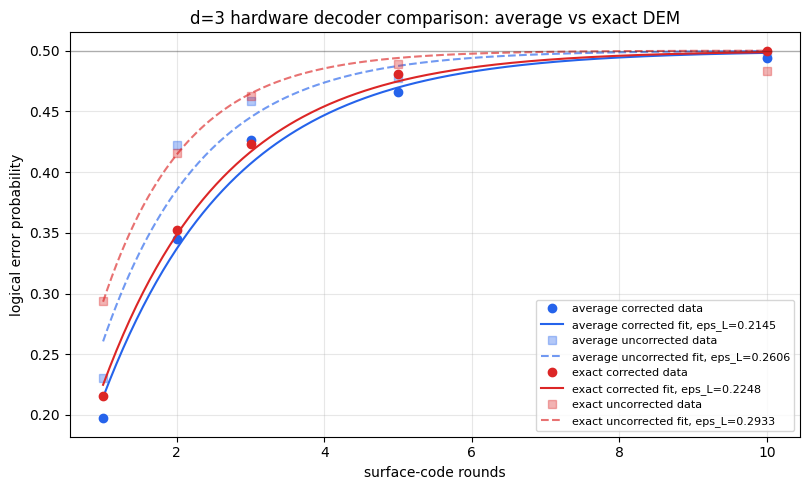

average: corrected eps_L=0.21453, uncorrected eps_L=0.26058, swap_count=0
exact: corrected eps_L=0.22481, uncorrected eps_L=0.29325, swap_count=0


In [84]:
fig, ax = plt.subplots(figsize=(8.2, 5.0))

colors = {
    "average": "#2563eb",
    "exact": "#dc2626",
}

for decoder_noise, out in d3_decoder_comparison.items():
    fit = out["fit"]
    rounds = np.asarray(fit["rounds"], dtype=float)
    xs = np.linspace(rounds.min(), rounds.max(), 300)

    corrected_eps = fit["corrected_fit"]["epsilon_l"]
    uncorrected_eps = fit["uncorrected_fit"]["epsilon_l"]

    color = colors[decoder_noise]

    ax.plot(
        rounds,
        fit["corrected_fit_prob"],
        "o",
        color=color,
        label=f"{decoder_noise} corrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, corrected_eps),
        "-",
        color=color,
        label=f"{decoder_noise} corrected fit, eps_L={corrected_eps:.4g}",
    )

    ax.plot(
        rounds,
        fit["uncorrected_fit_prob"],
        "s",
        color=color,
        alpha=0.35,
        label=f"{decoder_noise} uncorrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, uncorrected_eps),
        "--",
        color=color,
        alpha=0.65,
        label=f"{decoder_noise} uncorrected fit, eps_L={uncorrected_eps:.4g}",
    )

ax.axhline(0.5, color="black", lw=1, alpha=0.25)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title("d=3 hardware decoder comparison: average vs exact DEM")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

for decoder_noise, out in d3_decoder_comparison.items():
    s = out["summary"]
    print(
        f"{decoder_noise}: "
        f"corrected eps_L={s['logical_error_rate']:.5g}, "
        f"uncorrected eps_L={s['uncorrected_logical_error_rate']:.5g}, "
        f"swap_count={s.get('swap_count')}"
    )

The decoders are comparable, but interestingly the average one performs slightly better. This might be due to the exact detector error model overfitting the noise. However, if the calibration has been performed very recently, then the exact one might perform better. Since we are performing post-decoding, we can technically do both versions on every run and choose the one that works better.

# 4. Distance 3 surface code along defective coupler

Next, let us move on to defective lattices and show the usage of our SnL pipeline. We will run a d=3 surface code on a region of Emerald that would otherwise be unusable due to a defective coupler. It uses the Emerald patch around the top-center faulty region in the online device view where `QB24_QB32` was bad. The helper below returns the exact faulty region and defect arguments.

Found 1 defect clusters.
Loaded today's calibration data: calibration_data/2026-06-08T06_12_52.097243Z.json
Found 1 defect clusters.


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

rounds=3 | logical_error_probability=0.5014 | uncorrected=0.488 | swap_count=0 | job=019ea715-03be-7c81-8b25-3a21900e8e19


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

rounds=5 | logical_error_probability=0.4922 | uncorrected=0.4942 | swap_count=0 | job=019ea715-50f0-7660-853e-35cf5d300a24


Progress in queue:   0%|          | 0/2 [00:00<?, ?it/s]

rounds=10 | logical_error_probability=0.4884 | uncorrected=0.4942 | swap_count=0 | job=019ea715-ca72-74d1-a3ce-77bed964fe22


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

rounds=15 | logical_error_probability=0.4878 | uncorrected=0.507 | swap_count=0 | job=019ea716-4d82-7363-b5ee-a1df34b1885b


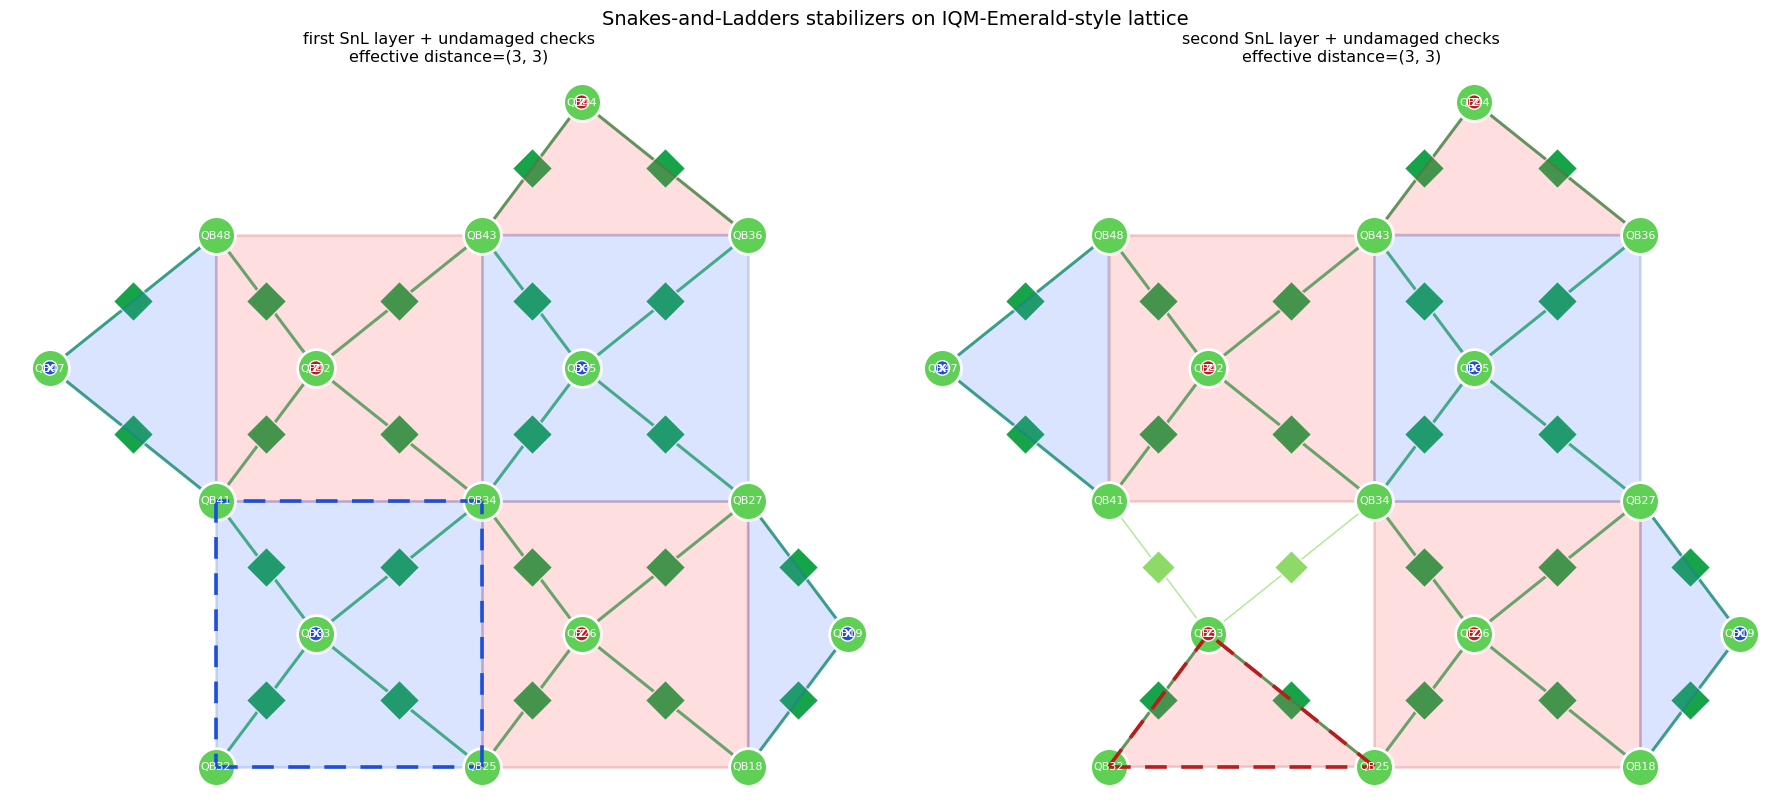

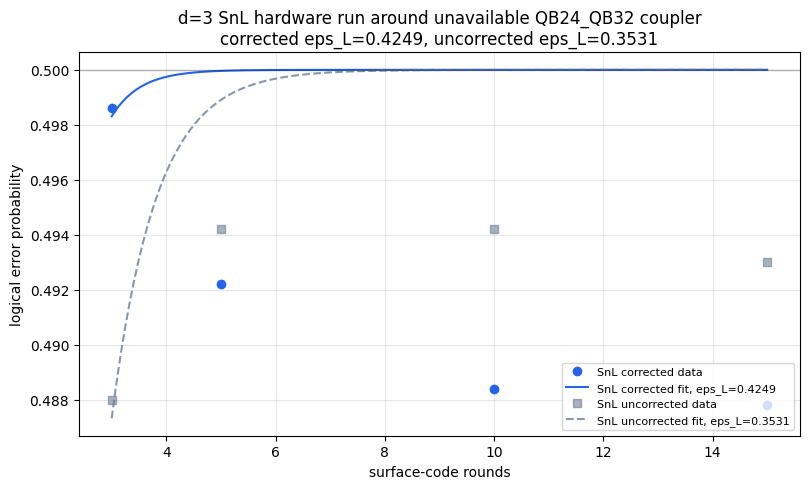

{'faulty_coupler': 'QB24_QB32',
 'logical_error_rate': 0.4249387748188741,
 'uncorrected_logical_error_rate': 0.3530985592977965,
 'swap_count': 0,
 'effective_distance': (3, 3),
 'defect_couplers': [(24, 32)]}

In [93]:
ROUND_VALUES = (3, 5, 10, 15)
FAULTY_COUPLER = "QB24_QB32"

faulty_region = snl.hardware_faulty_region_demo_kwargs(
    distance=3,
    defect_qubits=[],
    defect_couplers=[FAULTY_COUPLER],
    cal=CAL,
)

# SnL: use the faulty region and deform stabilizers around QB24-QB32.
snl_d3_faulty_coupler = snl.run_snl_round_sweep(
    distance=faulty_region["distance"],
    round_values=ROUND_VALUES,
    shots=SHOTS,
    mode="hardware",
    defect_qubits=faulty_region["defect_qubits"],
    defect_couplers=faulty_region["defect_couplers"],
    use_calibration_defects=faulty_region["use_calibration_defects"],
    basis=BASIS,
    cal=CAL,
    token=TOKEN,
    api_url=API_URL,
    sw_offset=faulty_region["sw_offset"],
    optimize_layout=False,
    show_lattice_plot=True,
    show_error_plot=False,
)

# Plot fitted SnL logical error probability vs rounds.
fit = snl_d3_faulty_coupler["fit"]
rounds = np.asarray(fit["rounds"], dtype=float)
xs = np.linspace(rounds.min(), rounds.max(), 300)
corrected_eps = fit["corrected_fit"]["epsilon_l"]
uncorrected_eps = fit["uncorrected_fit"]["epsilon_l"]

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(
    rounds,
    fit["corrected_fit_prob"],
    "o",
    color="#2563eb",
    label="SnL corrected data",
)
ax.plot(
    xs,
    iqm.logical_error_probability(xs, corrected_eps),
    "-",
    color="#2563eb",
    label=f"SnL corrected fit, eps_L={corrected_eps:.4g}",
)
ax.plot(
    rounds,
    fit["uncorrected_fit_prob"],
    "s",
    color="#64748b",
    alpha=0.55,
    label="SnL uncorrected data",
)
ax.plot(
    xs,
    iqm.logical_error_probability(xs, uncorrected_eps),
    "--",
    color="#64748b",
    alpha=0.75,
    label=f"SnL uncorrected fit, eps_L={uncorrected_eps:.4g}",
)

ax.axhline(0.5, color="black", lw=1, alpha=0.25)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title(
    f"d=3 SnL hardware run around unavailable {FAULTY_COUPLER} coupler\n"
    f"corrected eps_L={corrected_eps:.4g}, uncorrected eps_L={uncorrected_eps:.4g}"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

faulty_coupler_snl_summary = {
    "faulty_coupler": FAULTY_COUPLER,
    "logical_error_rate": snl_d3_faulty_coupler["summary"]["logical_error_rate"],
    "uncorrected_logical_error_rate": snl_d3_faulty_coupler["summary"]["uncorrected_logical_error_rate"],
    "swap_count": snl_d3_faulty_coupler["summary"].get("swap_count"),
    "effective_distance": snl_d3_faulty_coupler["summary"].get("effective_distance"),
    "defect_couplers": snl_d3_faulty_coupler["summary"].get("defect_couplers"),
}
faulty_coupler_snl_summary


With `show_lattice_plot=True` we show how the surface code stabilizers are deformed into two sets of deformed stabilizers (each round is split into two smaller rounds with altered stabilizers). These two sets of stabilizer measurements are shown above. The two rounds of deformed stabilizer measurements are used to infer the value of the measurement result that would have been performed if the coupler was working. The idea is to overcome the faulty coupler by letting other functioning couplers take over and perform some extra measurements. The way in which the stabilizers should be deformed is provided by the Snakes and Ladders algorithm.



Also, let us show what part of the emerald lattice we were utilizing and where the faulty coupler was.

used IQM qubits: [18, 19, 25, 26, 27, 32, 33, 34, 35, 36, 41, 42, 43, 44, 47, 48]
used IQM couplers: [(18, 19), (18, 26), (19, 27), (25, 26), (25, 33), (26, 27), (26, 34), (27, 35), (32, 33), (33, 34), (33, 41), (34, 35), (34, 42), (35, 36), (35, 43), (36, 44), (41, 42), (41, 47), (42, 43), (42, 48), (43, 44), (47, 48)]
defective couplers: [(24, 32)]


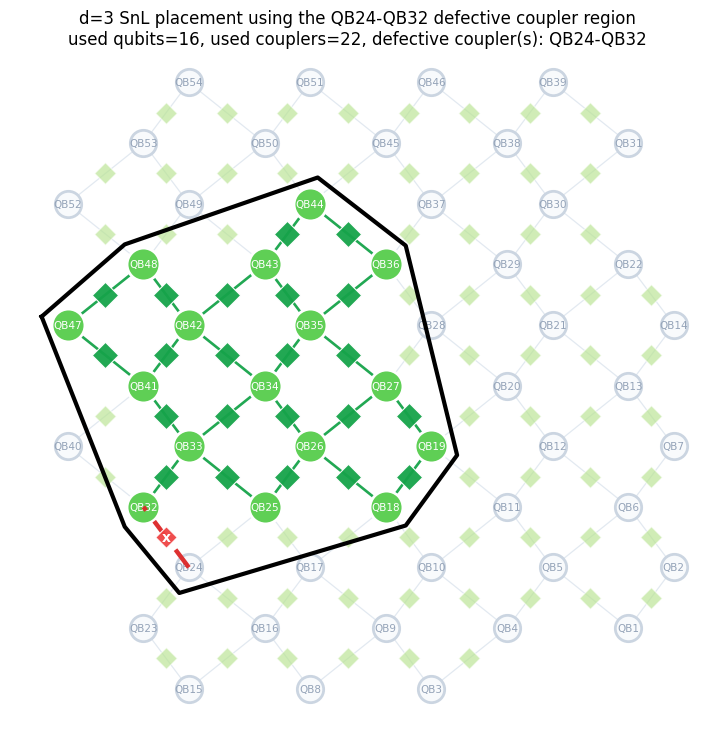

In [94]:
snl_d3_region_result = snl_d3_faulty_coupler["results"][0]
print("used IQM qubits:", sorted(hv.used_iqm_qubits(snl_d3_region_result)))
print("used IQM couplers:", sorted(hv.used_iqm_couplers(snl_d3_region_result)))
print("defective couplers:", snl_d3_region_result["summary"]["defect_couplers"])

snl_d3_hardware_region_fig = hv.plot_snl_emerald_hardware_region(
    snl_d3_region_result,
    title="d=3 SnL placement using the QB24-QB32 defective coupler region",
    show_full_lattice=True,
)

# 5. Synthetic d=5 SnL Code With a Central Data-Qubit Defect

In general we can have 3 types of defects:
- data qubit defect (worst type of defect)
- ancilla qubit defect 
- coupler defect

In the previous section we looked at a faulty coupler. Next let us use our pipeline with a defective data qubit in the center. We mark central `QB27` as unavailable. Below, we show the logical error rates as well as how the stabilizers are deformed. The deformed stabilizers around the defect are called "super stabilizers" since the stabilizer around the defect becomes quite large (combined weight 6), compared to the normal weight 4.

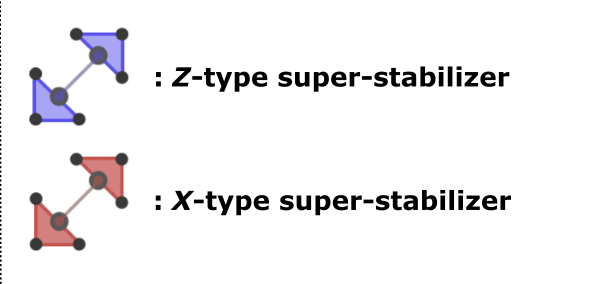

Loaded today's calibration data: calibration_data/2026-06-08T06_12_52.097243Z.json
Found 1 defect clusters.
rounds=1 | logical_error_probability=0.08 | uncorrected=0.2682 | swap_count=None | job=None
rounds=3 | logical_error_probability=0.1158 | uncorrected=0.3412 | swap_count=None | job=None
rounds=5 | logical_error_probability=0.149 | uncorrected=0.3824 | swap_count=None | job=None
rounds=10 | logical_error_probability=0.2154 | uncorrected=0.451 | swap_count=None | job=None


{'distance': 5,
 'round_values': [1, 3, 5, 10],
 'shots': 5000,
 'mode': 'synthetic',
 'effective_distance': (4, 4),
 'defect_qubits': [27],
 'defect_couplers': [],
 'use_calibration_defects': False,
 'optimize_layout': True,
 'sw_offset': (1, 1),
 'logical_error_rate': 0.03398260194800974,
 'uncorrected_logical_error_rate': 0.18398555195775979,
 'swap_count': None,
 'skipped_hardware_operation_count': 0}

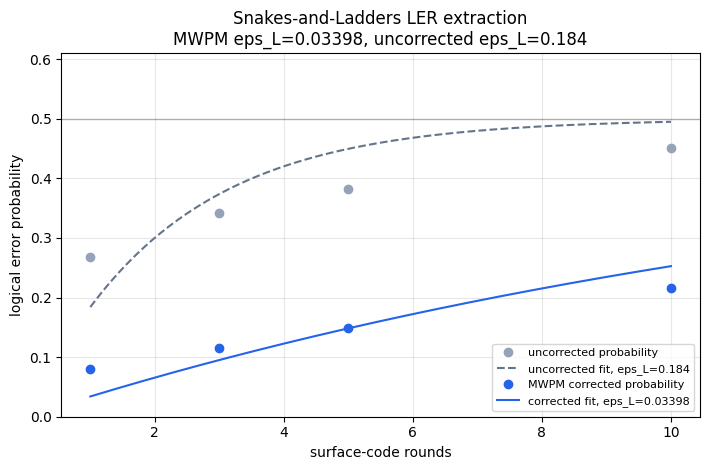

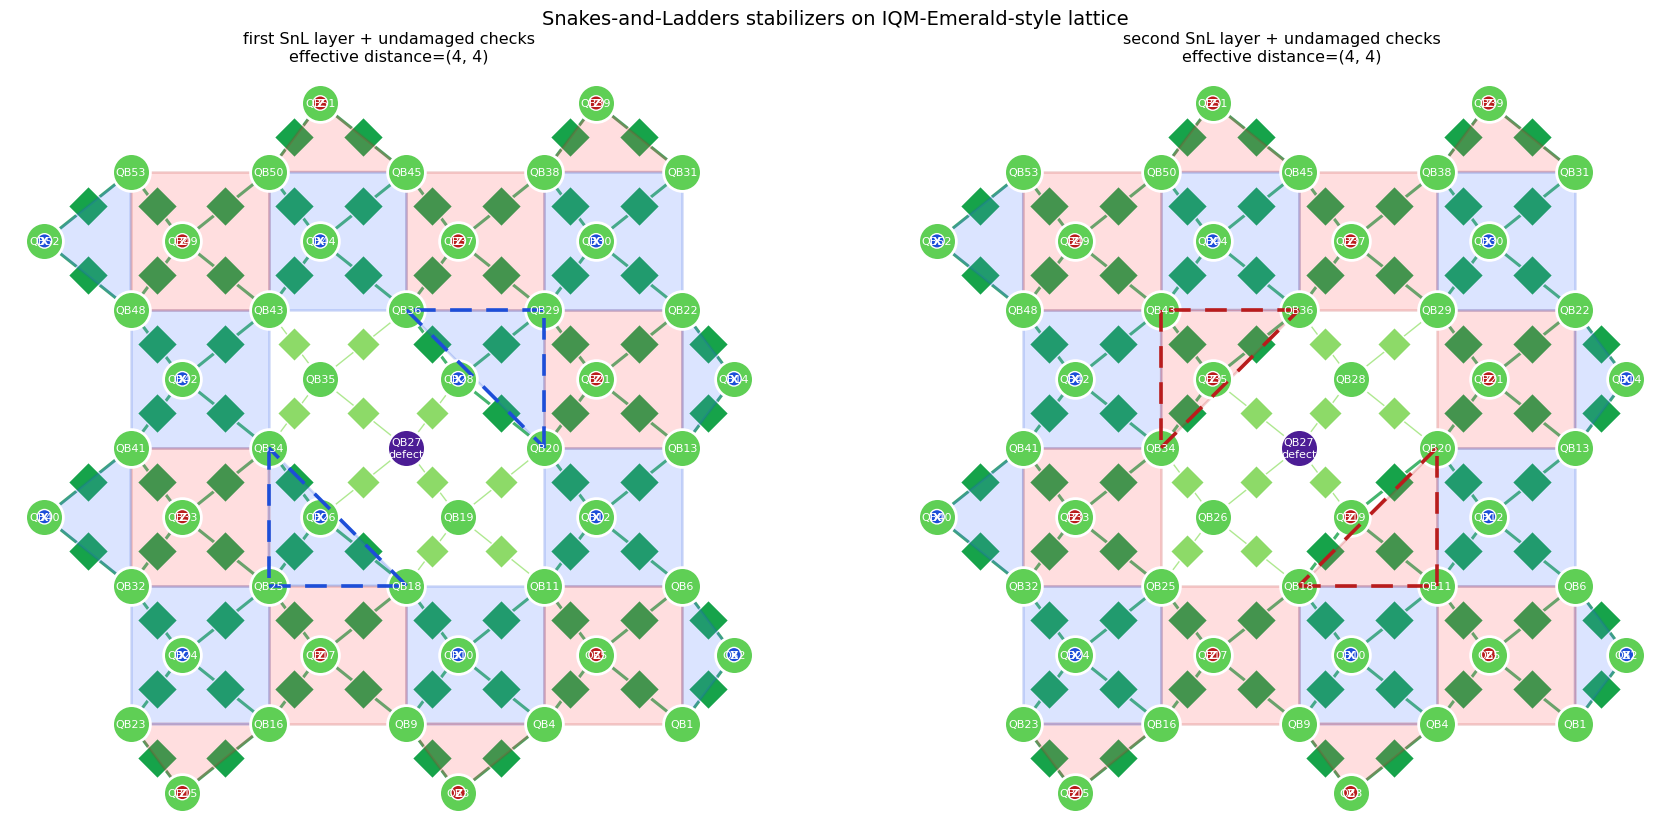

In [87]:
snl_d5_center_defect = snl.run_snl_round_sweep(
    distance=5,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    mode="synthetic",
    defect_qubits=[27],
    use_calibration_defects=False,
    basis=BASIS,
    cal=CAL,
    optimize_layout=True,
    show_lattice_plot=True,
    show_error_plot=True,
)

snl_d5_center_defect["summary"]

## Comparison

Let us compare the performance when we are using our SnL pipeline vs not. Use the same center data qubit defect.

Loaded today's calibration data: calibration_data/2026-06-08T06_12_52.097243Z.json
Found 1 defect clusters.
rounds=3 | logical_error_probability=0.1132 | uncorrected=0.3382 | swap_count=None | job=None
rounds=5 | logical_error_probability=0.1466 | uncorrected=0.3742 | swap_count=None | job=None
rounds=7 | logical_error_probability=0.1818 | uncorrected=0.4134 | swap_count=None | job=None
rounds=10 | logical_error_probability=0.2212 | uncorrected=0.4466 | swap_count=None | job=None
rounds=15 | logical_error_probability=0.2816 | uncorrected=0.4724 | swap_count=None | job=None
rounds=20 | logical_error_probability=0.3222 | uncorrected=0.4768 | swap_count=None | job=None
rounds=25 | logical_error_probability=0.3514 | uncorrected=0.4946 | swap_count=None | job=None
rounds=30 | logical_error_probability=0.4012 | uncorrected=0.4804 | swap_count=None | job=None
rounds=35 | logical_error_probability=0.422 | uncorrected=0.4826 | swap_count=None | job=None
rounds=40 | logical_error_probability=0.4

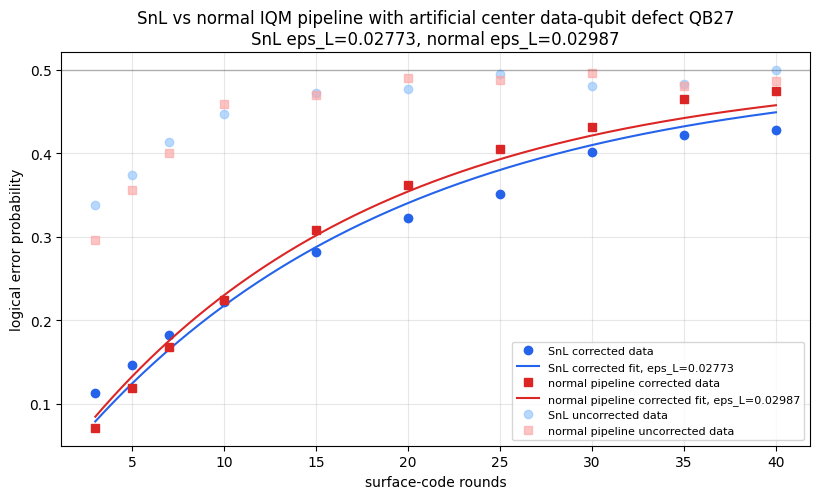

{'defect_iqm_qubit': 27,
 'defect_stim_qubit': 35,
 'defect_depolarization': 0.6,
 'snl_corrected_logical_error_rate': 0.027730083190415953,
 'normal_pipeline_corrected_logical_error_rate': 0.029865089595447977,
 'snl_uncorrected_logical_error_rate': 0.12913038739193697,
 'normal_pipeline_uncorrected_logical_error_rate': 0.11414284242921215}

In [98]:
# Compare SnL deformation against the normal IQM pipeline on the same artificial center defect.
#
# SnL:
#   Treat the center data qubit as unavailable and deform stabilizers around it.
# Normal IQM pipeline:
#   Keep the ordinary rotated surface-code stabilizers/layout, but in synthetic mode
#   add strong defect noise to the same center Stim data qubit.

ROUND_VALUES = (3, 5, 7, 10, 15, 20, 25, 30, 35, 40)
DEFECT_DEPOLARIZATION = 0.6

snl_d5_center_defect = snl.run_snl_round_sweep(
    distance=5,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    mode="synthetic",
    defect_qubits=[27],
    use_calibration_defects=False,
    basis=BASIS,
    cal=CAL,
    optimize_layout=False,
    show_lattice_plot=False,
    show_error_plot=False,
)

snl_reference_result = snl_d5_center_defect["results"][0]
center_defect_pos = next(iter(snl_reference_result["data_defects"]))
center_defect_stim_q = int(center_defect_pos)
center_defect_iqm_q = snl.COORD_TO_QB[center_defect_pos]
print(f"Same artificial center defect: Stim q={center_defect_stim_q}, IQM QB{center_defect_iqm_q}")

no_snl_center_defect = iqm.run_round_sweep(
    distance=5,
    round_values=ROUND_VALUES,
    shots=SHOTS,
    basis=BASIS,
    cal=CAL,
    run_mode="synthetic",
    decoder_noise="average",
    refresh_calibration=False,
    save_stim_file=False,
    optimize_layout=False,
    synthetic_defect_qubits=[center_defect_stim_q],
    synthetic_defect_probability=DEFECT_DEPOLARIZATION,
    show_error_plot=False,
)

snl_fit = snl_d5_center_defect["fit"]
no_snl_fit = no_snl_center_defect["fit"]
snl_rounds = np.asarray(snl_fit["rounds"], dtype=float)
no_snl_rounds = np.asarray(no_snl_fit["rounds"], dtype=float)
xs = np.linspace(min(snl_rounds.min(), no_snl_rounds.min()), max(snl_rounds.max(), no_snl_rounds.max()), 300)

fig, ax = plt.subplots(figsize=(8.3, 5.1))
ax.plot(snl_rounds, snl_fit["corrected_fit_prob"], "o", color="#2563eb", label="SnL corrected data")
ax.plot(
    xs,
    iqm.logical_error_probability(xs, snl_fit["corrected_fit"]["epsilon_l"]),
    "-",
    color="#2563eb",
    label=f"SnL corrected fit, eps_L={snl_fit['corrected_fit']['epsilon_l']:.4g}",
)
ax.plot(no_snl_rounds, no_snl_fit["corrected_fit_prob"], "s", color="#dc2626", label="normal pipeline corrected data")
ax.plot(
    xs,
    iqm.logical_error_probability(xs, no_snl_fit["corrected_fit"]["epsilon_l"]),
    "-",
    color="#dc2626",
    label=f"normal pipeline corrected fit, eps_L={no_snl_fit['corrected_fit']['epsilon_l']:.4g}",
)
ax.plot(snl_rounds, snl_fit["uncorrected_fit_prob"], "o", color="#93c5fd", alpha=0.65, label="SnL uncorrected data")
ax.plot(no_snl_rounds, no_snl_fit["uncorrected_fit_prob"], "s", color="#fca5a5", alpha=0.65, label="normal pipeline uncorrected data")
ax.axhline(0.5, color="black", lw=1, alpha=0.25)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title(
    f"SnL vs normal IQM pipeline with artificial center data-qubit defect QB{center_defect_iqm_q}\n"
    f"SnL eps_L={snl_fit['corrected_fit']['epsilon_l']:.4g}, normal eps_L={no_snl_fit['corrected_fit']['epsilon_l']:.4g}"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

comparison_summary = {
    "defect_iqm_qubit": center_defect_iqm_q,
    "defect_stim_qubit": center_defect_stim_q,
    "defect_depolarization": DEFECT_DEPOLARIZATION,
    "snl_corrected_logical_error_rate": snl_fit["corrected_fit"]["epsilon_l"],
    "normal_pipeline_corrected_logical_error_rate": no_snl_fit["corrected_fit"]["epsilon_l"],
    "snl_uncorrected_logical_error_rate": snl_fit["uncorrected_fit"]["epsilon_l"],
    "normal_pipeline_uncorrected_logical_error_rate": no_snl_fit["uncorrected_fit"]["epsilon_l"],
}
comparison_summary


# 6. Let's add more defects!

Adding random defects on a synthetic d=9 lattice to compare the normal pipeline against the Snakes-and-Ladders deformation pipeline.


# d=9 random-defect scaling demo: normal pipeline vs Snakes-and-Ladders.
# Each n draws n random unavailable objects inside the d=9 patch. Each object is
# randomly either a data qubit or a data-ancilla coupler. The SnL pipeline deforms
# the checks around those defects; the normal pipeline keeps the same d=9 layout
# but injects strong synthetic noise on the same qubits/couplers.

D9_DEFECT_DISTANCE = 9
D9_DEFECT_COUNTS = range(0, 6)
D9_ROUND_VALUES = (1, 2, 3, 5, 8, 10)
D9_SHOTS = 1_000              # increase for smoother final numbers
D9_SW_OFFSET = (1, 1)
D9_RANDOM_SEED = None         # set to an int for reproducible random defects
D9_DEFECT_PROBABILITY = 0.6   # synthetic depolarizing strength for unavailable objects


def _stim_coord_to_qubit(distance, basis=BASIS):
    c = iqm.stim_circuit(distance, 1, basis)
    return {
        tuple(int(round(v)) for v in coords[:2]): int(q)
        for q, coords in c.get_final_qubit_coordinates().items()
    }


def _draw_random_d9_snl_patch(num_defects, seed=None):
    rng = np.random.default_rng(seed)
    clean_patch = snl.RotatedSurfaceCode(
        D9_DEFECT_DISTANCE,
        sw_offset=snl.Pos(*D9_SW_OFFSET),
        vertical_logical=snl.PauliT.Z,
    )

    data_pool = [p for p in clean_patch.data_qubits if not snl.is_boundary_pos(clean_patch, p)]
    data_defects = set()
    link_defects = set()

    for _ in range(num_defects):
        choose_data = rng.random() < 0.5
        if choose_data and data_pool:
            idx = int(rng.integers(len(data_pool)))
            data_defects.add(data_pool.pop(idx))
            continue

        link_pool = [
            link for link in snl.stabilizer_links(clean_patch)
            if link not in link_defects
            and link[0] not in data_defects
            and link[1] not in data_defects
            and not snl.is_boundary_pos(clean_patch, link[0])
            and not snl.is_boundary_pos(clean_patch, link[1])
        ]
        if link_pool:
            link_defects.add(link_pool[int(rng.integers(len(link_pool)))])
        elif data_pool:
            idx = int(rng.integers(len(data_pool)))
            data_defects.add(data_pool.pop(idx))

    _, damaged_patches = snl.DefectiveSurfaceCode.make_defective_patches(
        clean_patch,
        ancilla_defects=set(),
        data_defects=data_defects,
        link_defects=link_defects,
        repurpose_ancillas=True,
        add_padding=True,
        first_super_type=snl.PauliT.X,
        use_heuristics=snl.Heuristics(n_sol_max_per_cluster=10, n_sol_max=50, n_skip=5),
    )
    if not damaged_patches:
        raise RuntimeError(f"SnL could not construct a damaged patch for n={num_defects} defects")

    damaged_patch = max(damaged_patches, key=lambda p: min(p.effective_distance))
    return {
        "clean_patch": clean_patch,
        "damaged_patch": damaged_patch,
        "data_defects": data_defects,
        "ancilla_defects": set(),
        "link_defects": link_defects,
        "defect_qubits": [],
        "defect_couplers": [],
        "calibration_info": {},
        "use_calibration_defects": False,
        "sw_offset": D9_SW_OFFSET,
        "seed": seed,
        "optimize_layout": False,
    }


def _patch_defects_to_stim_defects(patch_data, distance=D9_DEFECT_DISTANCE, basis=BASIS):
    coord_to_q = _stim_coord_to_qubit(distance, basis)
    q_defects = [
        coord_to_q[(int(p.x), int(p.y))]
        for p in patch_data["data_defects"]
        if (int(p.x), int(p.y)) in coord_to_q
    ]
    coupler_defects = []
    for a, b in patch_data["link_defects"]:
        ca = (int(a.x), int(a.y))
        cb = (int(b.x), int(b.y))
        if ca in coord_to_q and cb in coord_to_q:
            coupler_defects.append(tuple(sorted((coord_to_q[ca], coord_to_q[cb]))))
    return sorted(q_defects), sorted(coupler_defects)


def _run_snl_synthetic_sweep_from_patch(patch_data):
    results = []
    for rounds in D9_ROUND_VALUES:
        result = snl.run_one_round_count(
            patch_data=patch_data,
            rounds=int(rounds),
            shots=D9_SHOTS,
            mode="synthetic",
            basis=BASIS,
            cal=CAL,
        )
        result["calibration_path"] = CAL
        results.append(result)

    fit = snl.fit_snl_round_sweep(results)
    return {
        "results": results,
        "fit": fit,
        "summary": {
            "distance": D9_DEFECT_DISTANCE,
            "round_values": list(D9_ROUND_VALUES),
            "shots": D9_SHOTS,
            "mode": "synthetic",
            "logical_error_rate": fit["corrected_fit"]["epsilon_l"],
            "uncorrected_logical_error_rate": fit["uncorrected_fit"]["epsilon_l"],
            "effective_distance": results[0]["summary"]["effective_distance"],
            "num_data_defects": len(patch_data["data_defects"]),
            "num_coupler_defects": len(patch_data["link_defects"]),
        },
    }


def _plot_defect_scaling(defect_results):
    ns = np.array(sorted(defect_results), dtype=int)
    snl_ler = np.array([defect_results[int(n)]["snl"]["summary"]["logical_error_rate"] for n in ns], dtype=float)
    normal_ler = np.array([defect_results[int(n)]["normal"]["summary"]["logical_error_rate"] for n in ns], dtype=float)
    floor = 1 / (10 * max(D9_SHOTS, 1))

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ax.plot(ns, np.maximum(normal_ler, floor), "s-", color="#dc2626", label="normal d=9 with same synthetic defects")
    ax.plot(ns, np.maximum(snl_ler, floor), "o-", color="#2563eb", label="SnL deformed d=9")
    ax.set_yscale("log")
    ax.set_xlabel("number of random unavailable data qubits/couplers")
    ax.set_ylabel("fitted logical error rate per round")
    ax.set_title("d=9 synthetic defect scaling using calibration noise")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best")

    for n, y in zip(ns, normal_ler):
        ax.annotate(f"{y:.2g}", (n, max(y, floor)), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color="#991b1b")
    for n, y in zip(ns, snl_ler):
        ax.annotate(f"{y:.2g}", (n, max(y, floor)), textcoords="offset points", xytext=(0, -13), ha="center", fontsize=8, color="#1d4ed8")

    fig.tight_layout()
    plt.show()
    return fig


d9_defect_scaling = {}
base_seed_sequence = np.random.SeedSequence(D9_RANDOM_SEED)
case_seeds = base_seed_sequence.spawn(len(list(D9_DEFECT_COUNTS)))

for n, seed_sequence in zip(D9_DEFECT_COUNTS, case_seeds):
    seed = int(seed_sequence.generate_state(1)[0])
    patch_data = _draw_random_d9_snl_patch(n, seed=seed)
    stim_q_defects, stim_coupler_defects = _patch_defects_to_stim_defects(patch_data)

    print(
        f"\n=== d=9 random defects n={n} | "
        f"data defects={len(stim_q_defects)} | coupler defects={len(stim_coupler_defects)} ==="
    )
    print("Stim data-qubit defects:", stim_q_defects)
    print("Stim coupler defects:", stim_coupler_defects)

    snl_out = _run_snl_synthetic_sweep_from_patch(patch_data)
    normal_out = iqm.run_round_sweep(
        distance=D9_DEFECT_DISTANCE,
        round_values=D9_ROUND_VALUES,
        shots=D9_SHOTS,
        basis=BASIS,
        cal=CAL,
        run_mode="synthetic",
        decoder_noise="average",
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=False,
        synthetic_defect_qubits=stim_q_defects,
        synthetic_defect_couplers=stim_coupler_defects,
        synthetic_defect_probability=D9_DEFECT_PROBABILITY,
        show_error_plot=False,
    )

    d9_defect_scaling[n] = {
        "patch_data": patch_data,
        "stim_data_qubit_defects": stim_q_defects,
        "stim_coupler_defects": stim_coupler_defects,
        "snl": snl_out,
        "normal": normal_out,
    }

    hv.plot_snl_superstabilizer_rounds(
        snl_out["results"][0],
        title=f"d=9 SnL damaged lattice, random defects n={n}",
    )
    plt.show()

_plot_defect_scaling(d9_defect_scaling)

print("\nFitted logical error rates per round")
for n, out in d9_defect_scaling.items():
    print(
        f"n={n}: SnL eps_L={out['snl']['summary']['logical_error_rate']:.4g}, "
        f"normal eps_L={out['normal']['summary']['logical_error_rate']:.4g}, "
        f"data defects={out['stim_data_qubit_defects']}, coupler defects={out['stim_coupler_defects']}"
    )



Base pipeline logical error probability: 0.038
rounds=1 | corrected_prob=0.03 | uncorrected_prob=0.106 | skipped_ops=0 | job=None
rounds=2 | corrected_prob=0.048 | uncorrected_prob=0.158 | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.044 | uncorrected_prob=0.134 | skipped_ops=0 | job=None
Base pipeline logical error rate per round: 0.0193800581402907
Found 1 defect clusters.
SnL logical error probability: 0.062
Found 1 defect clusters.
rounds=1 | logical_error_probability=0.058 | uncorrected=0.194 | job=None
rounds=2 | logical_error_probability=0.076 | uncorrected=0.208 | job=None
rounds=3 | logical_error_probability=0.09 | uncorrected=0.242 | job=None
SnL logical error rate per round: 0.037695113085565425


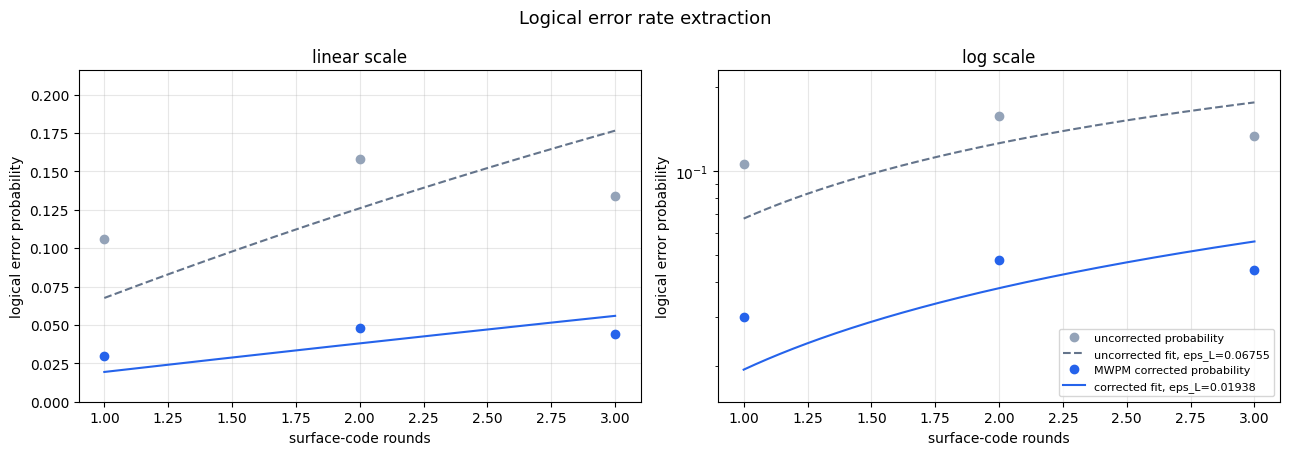

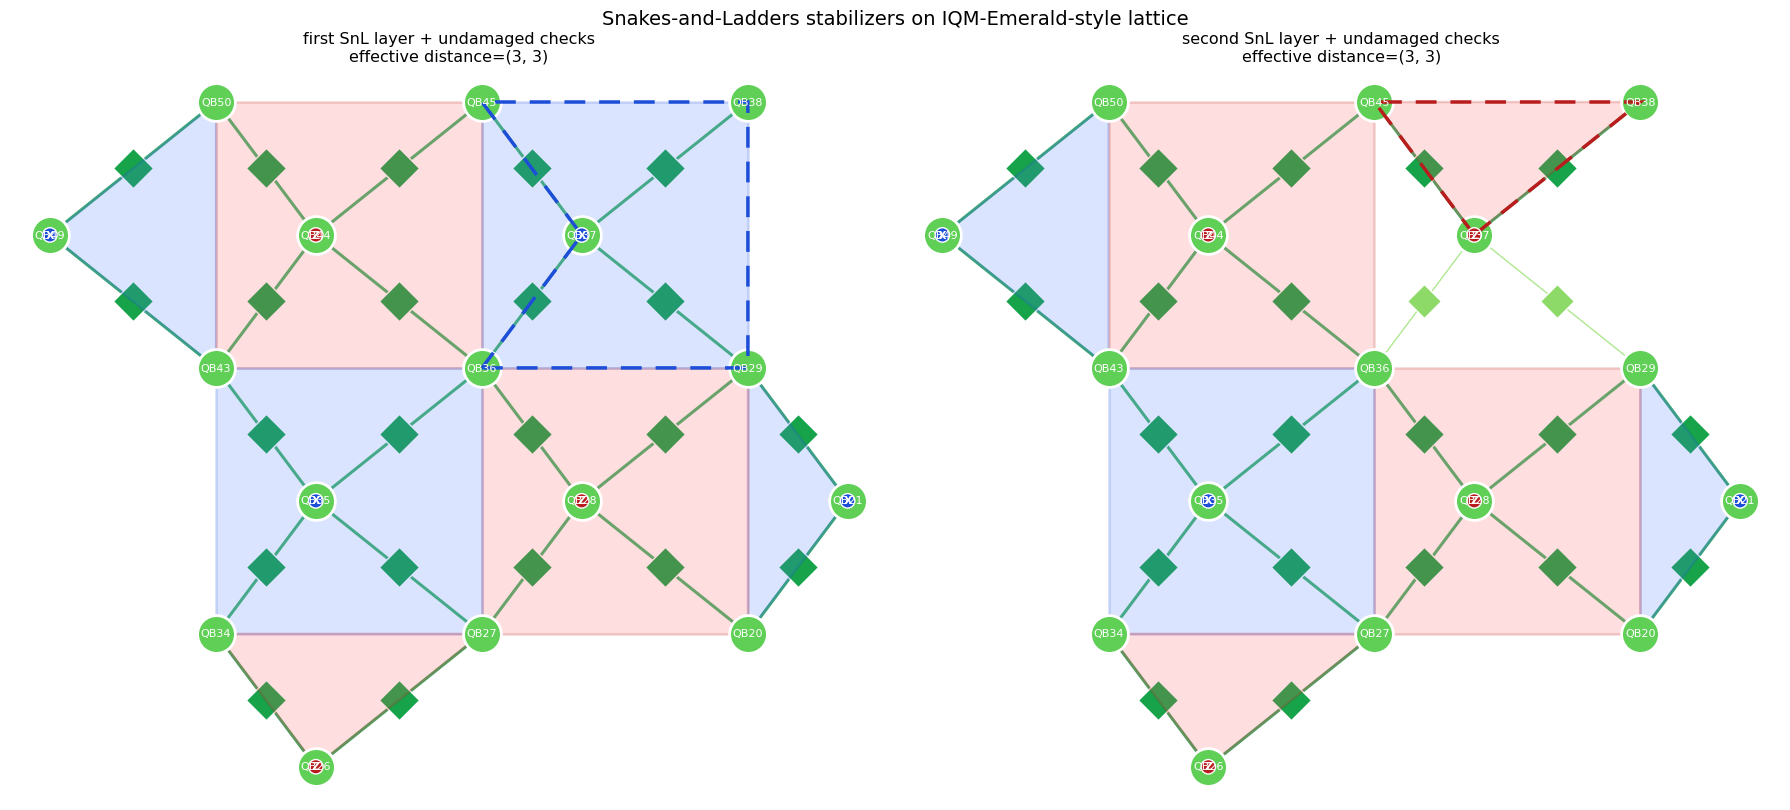

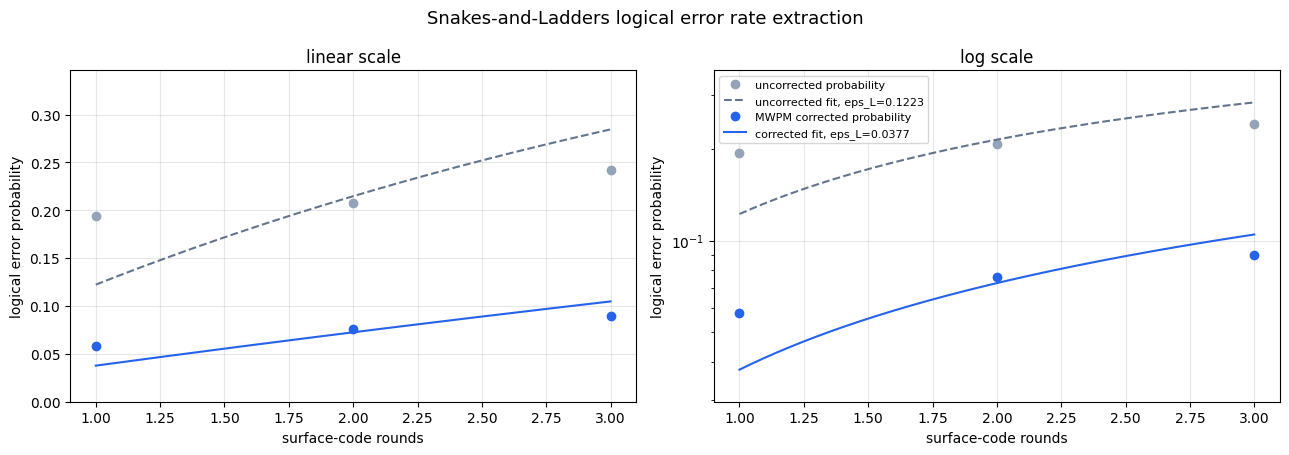

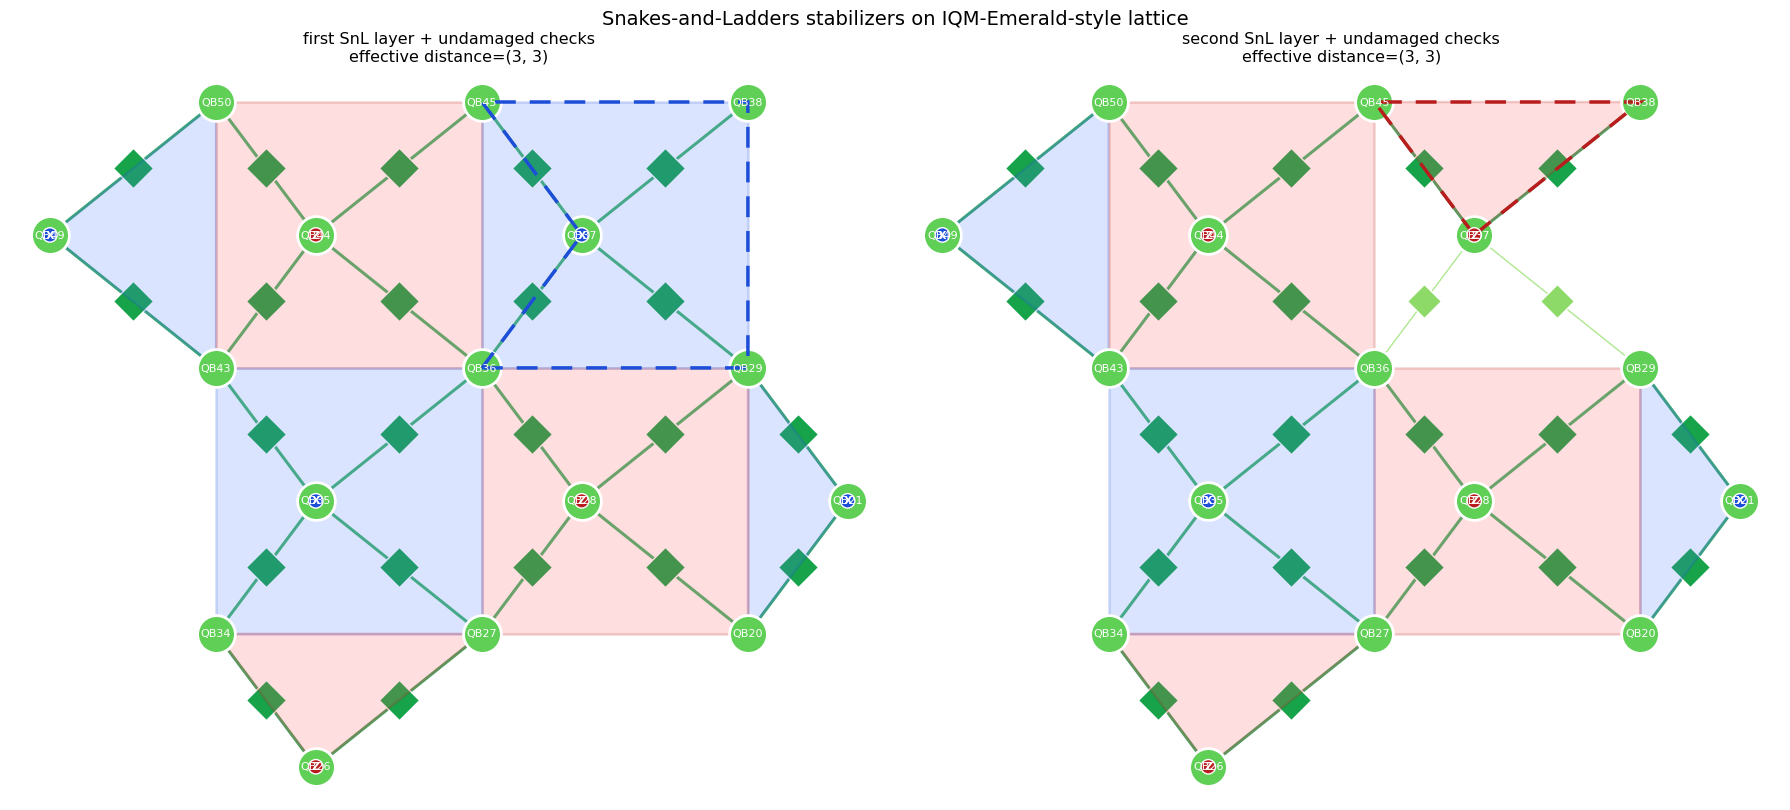

In [4]:
# Tutorial settings: small synthetic jobs so this cell can be run without submitting hardware jobs.
TUTORIAL_DISTANCE = 3          # surface-code distance d
TUTORIAL_ROUNDS = 3            # number of QEC rounds for one logical-error-probability estimate
TUTORIAL_ROUND_VALUES = (1, 2, 3)  # round counts used to fit logical error rate per round
TUTORIAL_SHOTS = 500           # shots per experiment; increase for smoother estimates
TUTORIAL_BASIS = "Z"           # memory basis: "Z" or "X"
TUTORIAL_DECODER_NOISE = "average"  # decoder noise model: "average" or "exact"


# -----------------------------------------------------------------------------
# 1. Base IQM pipeline: one logical error probability measurement
# -----------------------------------------------------------------------------
# iqm.run_pipeline parameters:
#   distance: code distance.
#   rounds: number of surface-code cycles.
#   shots: number of sampled/hardware shots.
#   basis: logical memory basis, "Z" or "X".
#   cal: calibration JSON used for layout/noise.
#   run_mode: "synthetic" samples from calibration noise; "hardware" submits to IQM.
#   decoder_noise: "average" compact calibration model or "exact" qubit/coupler-specific model.
#   refresh_calibration: if True, try to fetch today's IQM calibration data.
#   save_stim_file: if True, write the generated Stim circuit into stim_files/.
#   optimize_layout: choose best IQM Emerald placement; useful/automatic for hardware.
base_probability = iqm.run_pipeline(
    distance=TUTORIAL_DISTANCE,
    rounds=TUTORIAL_ROUNDS,
    shots=TUTORIAL_SHOTS,
    basis=TUTORIAL_BASIS,
    cal=CAL,
    run_mode="synthetic",
    decoder_noise=TUTORIAL_DECODER_NOISE,
    refresh_calibration=False,
    save_stim_file=False,
    optimize_layout=False,
)
print("Base pipeline logical error probability:", base_probability["summary"]["corrected_ler"])


# -----------------------------------------------------------------------------
# 2. Base IQM pipeline: logical error rate extraction from a round sweep
# -----------------------------------------------------------------------------
# iqm.run_round_sweep parameters are the same as run_pipeline, except:
#   round_values: list/tuple of rounds to run separately.
#   show_error_plot: if True, return the fitted linear/log logical-error plot.
# The fitted per-round logical error rate is summary["logical_error_rate"].
base_sweep = iqm.run_round_sweep(
    distance=TUTORIAL_DISTANCE,
    round_values=TUTORIAL_ROUND_VALUES,
    shots=TUTORIAL_SHOTS,
    basis=TUTORIAL_BASIS,
    cal=CAL,
    run_mode="synthetic",
    decoder_noise=TUTORIAL_DECODER_NOISE,
    refresh_calibration=False,
    save_stim_file=False,
    optimize_layout=False,
    show_error_plot=True,
)
print("Base pipeline logical error rate per round:", base_sweep["summary"]["logical_error_rate"])


# -----------------------------------------------------------------------------
# 3. Snakes-and-Ladders pipeline: one logical error probability measurement
# -----------------------------------------------------------------------------
# snl.run_snl_pipeline parameters:
#   distance, rounds, shots, basis, cal: same meaning as the base pipeline.
#   mode: "synthetic" or "hardware".
#   num_qubit_defects / num_coupler_defects: randomly place this many unavailable components.
#   defect_qubits: explicit IQM qubits to treat as unavailable, e.g. [27] or ["QB27"].
#   defect_couplers: explicit IQM couplers to treat as unavailable, e.g. ["QB24_QB32"].
#   use_calibration_defects: include genuinely unavailable components from calibration/backend.
#   optimize_layout: scan Emerald placements and choose the best valid SnL patch.
#   sw_offset: fixed patch placement when optimize_layout=False.
#   show_plot: return a lattice visualization.
snl_probability = snl.run_snl_pipeline(
    distance=TUTORIAL_DISTANCE,
    rounds=TUTORIAL_ROUNDS,
    shots=TUTORIAL_SHOTS,
    mode="synthetic",
    defect_couplers=["QB24_QB32"],
    use_calibration_defects=False,
    basis=TUTORIAL_BASIS,
    cal=CAL,
    sw_offset=(1, 3),
    optimize_layout=False,
    refresh_calibration=False,
    show_plot=True,
)
print("SnL logical error probability:", snl_probability["summary"]["logical_error_probability"])


# -----------------------------------------------------------------------------
# 4. Snakes-and-Ladders pipeline: logical error rate extraction from a round sweep
# -----------------------------------------------------------------------------
# snl.run_snl_round_sweep parameters match run_snl_pipeline, except:
#   round_values: list/tuple of rounds to run separately on the same deformed patch.
#   show_lattice_plot: return the SnL lattice/defect visualization.
#   show_error_plot: return the fitted linear/log logical-error plot.
# The fitted per-round logical error rate is summary["logical_error_rate"].
snl_sweep = snl.run_snl_round_sweep(
    distance=TUTORIAL_DISTANCE,
    round_values=TUTORIAL_ROUND_VALUES,
    shots=TUTORIAL_SHOTS,
    mode="synthetic",
    defect_couplers=["QB24_QB32"],
    use_calibration_defects=False,
    basis=TUTORIAL_BASIS,
    cal=CAL,
    sw_offset=(1, 3),
    optimize_layout=False,
    refresh_calibration=False,
    show_lattice_plot=True,
    show_error_plot=True,
)
print("SnL logical error rate per round:", snl_sweep["summary"]["logical_error_rate"])


## Full Functionality Plots

This section contains ready-to-run cells for project-level plots: exact-vs-average decoder comparison on d=3, clean synthetic distance scaling, and Snakes-and-Ladders one-defect distance scaling. The hardware comparison is guarded by a flag so the notebook does not accidentally submit IQM jobs.

rounds=1 | corrected_prob=0.03 | uncorrected_prob=0.1146 | skipped_ops=0 | job=None
rounds=2 | corrected_prob=0.0382 | uncorrected_prob=0.14 | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.054 | uncorrected_prob=0.176 | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.0722 | uncorrected_prob=0.2224 | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.111 | uncorrected_prob=0.2856 | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.1328 | uncorrected_prob=0.323 | skipped_ops=0 | job=None
rounds=1 | corrected_prob=0.0314 | uncorrected_prob=0.1152 | skipped_ops=0 | job=None
rounds=2 | corrected_prob=0.0458 | uncorrected_prob=0.1502 | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.051 | uncorrected_prob=0.167 | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.0804 | uncorrected_prob=0.2134 | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.106 | uncorrected_prob=0.2726 | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.1276 | uncorrected_prob=0.296 | ski

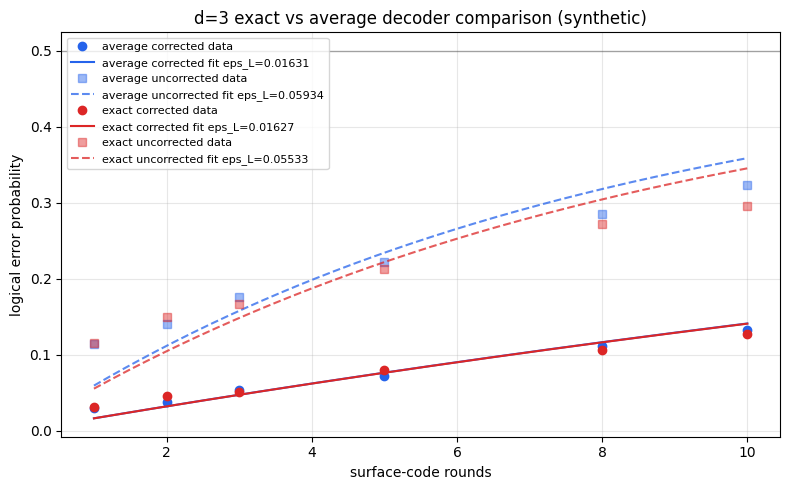

In [13]:
# -----------------------------------------------------------------------------
# Full functionality showcase: decoder comparison + distance scaling plots
# -----------------------------------------------------------------------------
# This cell intentionally uses synthetic mode for the larger distance sweeps.
# The d=3 exact-vs-average decoder comparison can be run on hardware by setting
# RUN_D3_HARDWARE_DECODER_COMPARISON = True.

import numpy as np
import matplotlib.pyplot as plt

DISTANCES = (3, 5, 7, 9, 11)
SCALING_ROUNDS = (1, 2, 3, 5, 8, 10)
SCALING_SHOTS = 2_000          # increase for smoother final plots
D3_COMPARISON_SHOTS = 5_000    # hardware comparison shots per round
DEFECT_SEED = 1234             # fixed so the synthetic defect comparison is reproducible


def print_ler_table(title, results_by_label):
    print("\n" + title)
    print("-" * len(title))
    for label, out in results_by_label.items():
        s = out["summary"]
        print(
            f"{label}: corrected eps_L={s['logical_error_rate']:.5g}, "
            f"uncorrected eps_L={s['uncorrected_logical_error_rate']:.5g}"
        )


def plot_distance_ler(clean_results, defect_results):
    """Plot fitted logical error rate per round vs distance on linear scale only."""
    distances = np.array(sorted(clean_results), dtype=float)
    clean_corr = np.array([clean_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
    clean_unc = np.array([clean_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])
    defect_corr = np.array([defect_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
    defect_unc = np.array([defect_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    ax.plot(distances, clean_corr, "o-", label="clean, MWPM corrected")
    ax.plot(distances, clean_unc, "o--", label="clean, uncorrected")
    ax.plot(distances, defect_corr, "s-", label="SnL one defect, MWPM corrected")
    ax.plot(distances, defect_unc, "s--", label="SnL one defect, uncorrected")
    for xs, ys in [(distances, clean_corr), (distances, clean_unc), (distances, defect_corr), (distances, defect_unc)]:
        for x0, y0 in zip(xs, ys):
            ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
    ax.set_xlabel("surface-code distance")
    ax.set_ylabel("logical error rate per round")
    ax.set_title("Distance scaling with calibration-derived noise")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


# -----------------------------------------------------------------------------
# A. d=3 exact-vs-average decoder model comparison
# -----------------------------------------------------------------------------
# Set this True to submit two real d=3 hardware round sweeps, one decoded with
# the exact calibration model and one decoded with the average calibration model.
# If False, the same comparison is run in synthetic mode

RUN_D3_HARDWARE_DECODER_COMPARISON = False
d3_comparison_mode = "hardware" if RUN_D3_HARDWARE_DECODER_COMPARISON else "synthetic"

d3_decoder_comparison = {}
for decoder_noise in ("average", "exact"):
    d3_decoder_comparison[decoder_noise] = iqm.run_round_sweep(
        distance=3,
        round_values=SCALING_ROUNDS,
        shots=D3_COMPARISON_SHOTS,
        basis=BASIS,
        cal=CAL,
        token=TOKEN,
        api_url=API_URL,
        run_mode=d3_comparison_mode,
        decoder_noise=decoder_noise,
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=(d3_comparison_mode == "hardware"),
        show_error_plot=False,
    )

print_ler_table(f"d=3 decoder comparison ({d3_comparison_mode})", d3_decoder_comparison)

fig, ax = plt.subplots(figsize=(8.0, 5.0))
colors = {"average": "#2563eb", "exact": "#dc2626"}
for label, out in d3_decoder_comparison.items():
    fit = out["fit"]
    rounds = np.asarray(fit["rounds"], dtype=float)
    xs = np.linspace(rounds.min(), rounds.max(), 300)
    corrected_eps = fit["corrected_fit"]["epsilon_l"]
    uncorrected_eps = fit["uncorrected_fit"]["epsilon_l"]
    color = colors.get(label, None)
    ax.plot(rounds, fit["corrected_fit_prob"], "o", color=color, label=f"{label} corrected data")
    ax.plot(xs, iqm.logical_error_probability(xs, corrected_eps), "-", color=color, label=f"{label} corrected fit eps_L={corrected_eps:.4g}")
    ax.plot(rounds, fit["uncorrected_fit_prob"], "s", color=color, alpha=0.45, label=f"{label} uncorrected data")
    ax.plot(xs, iqm.logical_error_probability(xs, uncorrected_eps), "--", color=color, alpha=0.75, label=f"{label} uncorrected fit eps_L={uncorrected_eps:.4g}")
ax.axhline(0.5, color="black", lw=1, alpha=0.3)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title(f"d=3 exact vs average decoder comparison ({d3_comparison_mode})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

# # -----------------------------------------------------------------------------
# # B. Clean/perfect lattice synthetic distance scaling, d = 3, 5, 7, 9, 11
# # -----------------------------------------------------------------------------
# # The normal pipeline uses the calibration-derived average noise model here.
# # This is the clean reference: no artificial unavailable qubits/couplers.
# clean_distance_results = {}
# for distance in DISTANCES:
#     clean_distance_results[distance] = iqm.run_round_sweep(
#         distance=distance,
#         round_values=SCALING_ROUNDS,
#         shots=SCALING_SHOTS,
#         basis=BASIS,
#         cal=CAL,
#         run_mode="synthetic",
#         decoder_noise="average",
#         refresh_calibration=False,
#         save_stim_file=False,
#         optimize_layout=False,
#         show_error_plot=True,
#     )

# print_ler_table("Clean synthetic distance scaling", {str(k): v for k, v in clean_distance_results.items()})


# # -----------------------------------------------------------------------------
# # C. Snakes-and-Ladders synthetic distance scaling with one unavailable qubit
# # -----------------------------------------------------------------------------
# # This tests the same distance sweep with one interior defect per code.
# # SnL deforms the stabilizers around the defect, then Stim/PyMatching decodes.
# defect_distance_results = {}
# for distance in DISTANCES:
#     defect_distance_results[distance] = snl.run_snl_round_sweep(
#         distance=distance,
#         round_values=SCALING_ROUNDS,
#         shots=SCALING_SHOTS,
#         mode="synthetic",
#         num_qubit_defects=1,
#         num_coupler_defects=0,
#         seed=DEFECT_SEED + distance,
#         use_calibration_defects=False,
#         basis=BASIS,
#         cal=CAL,
#         optimize_layout=False,
#         refresh_calibration=False,
#         show_lattice_plot=True,
#         show_error_plot=True,
#     )

# print_ler_table("SnL one-defect synthetic distance scaling", {str(k): v for k, v in defect_distance_results.items()})


# # -----------------------------------------------------------------------------
# # D. Combined distance-scaling plot on linear scale
# # -----------------------------------------------------------------------------
# distance_scaling_fig = plot_distance_ler(clean_distance_results, defect_distance_results)
# distance_scaling_fig


rounds=1 | corrected_prob=0.037 | uncorrected_prob=0.117 | skipped_ops=0 | job=None
rounds=2 | corrected_prob=0.046 | uncorrected_prob=0.1445 | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.057 | uncorrected_prob=0.18 | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.084 | uncorrected_prob=0.2325 | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.112 | uncorrected_prob=0.296 | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.145 | uncorrected_prob=0.3115 | skipped_ops=0 | job=None
rounds=1 | corrected_prob=0.024 | uncorrected_prob=0.197 | skipped_ops=0 | job=None
rounds=2 | corrected_prob=0.0305 | uncorrected_prob=0.248 | skipped_ops=0 | job=None
rounds=3 | corrected_prob=0.0415 | uncorrected_prob=0.245 | skipped_ops=0 | job=None
rounds=5 | corrected_prob=0.056 | uncorrected_prob=0.2995 | skipped_ops=0 | job=None
rounds=8 | corrected_prob=0.084 | uncorrected_prob=0.367 | skipped_ops=0 | job=None
rounds=10 | corrected_prob=0.1085 | uncorrected_prob=0.3985 | skipped_

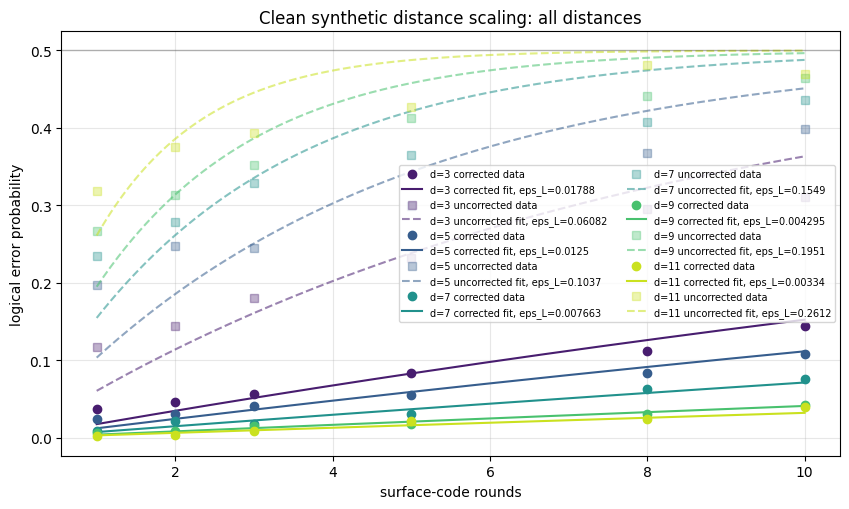

In [17]:
# -----------------------------------------------------------------------------
# B. Clean/perfect lattice synthetic distance scaling, d = 3, 5, 7, 9, 11
# -----------------------------------------------------------------------------
# The normal pipeline uses the calibration-derived average noise model here.
# This is the clean reference: no artificial unavailable qubits/couplers.
clean_distance_results = {}
for distance in DISTANCES:
    clean_distance_results[distance] = iqm.run_round_sweep(
        distance=distance,
        round_values=SCALING_ROUNDS,
        shots=SCALING_SHOTS,
        basis=BASIS,
        cal=CAL,
        run_mode="synthetic",
        decoder_noise="average",
        refresh_calibration=False,
        save_stim_file=False,
        optimize_layout=False,
        show_error_plot=False,
    )

print_ler_table("Clean synthetic distance scaling", {str(k): v for k, v in clean_distance_results.items()})

# Combined clean distance-scaling plot: all distances in one linear-scale figure.
fig, ax = plt.subplots(figsize=(8.6, 5.2))
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(clean_distance_results)))
for color, distance in zip(colors, sorted(clean_distance_results)):
    out = clean_distance_results[distance]
    fit = out["fit"]
    rounds = np.asarray(fit["rounds"], dtype=float)
    xs = np.linspace(rounds.min(), rounds.max(), 300)
    corrected_eps = fit["corrected_fit"]["epsilon_l"]
    uncorrected_eps = fit["uncorrected_fit"]["epsilon_l"]

    ax.plot(
        rounds,
        fit["corrected_fit_prob"],
        "o",
        color=color,
        label=f"d={distance} corrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, corrected_eps),
        "-",
        color=color,
        label=f"d={distance} corrected fit, eps_L={corrected_eps:.4g}",
    )
    ax.plot(
        rounds,
        fit["uncorrected_fit_prob"],
        "s",
        color=color,
        alpha=0.35,
        label=f"d={distance} uncorrected data",
    )
    ax.plot(
        xs,
        iqm.logical_error_probability(xs, uncorrected_eps),
        "--",
        color=color,
        alpha=0.55,
        label=f"d={distance} uncorrected fit, eps_L={uncorrected_eps:.4g}",
    )

ax.axhline(0.5, color="black", lw=1, alpha=0.25)
ax.set_xlabel("surface-code rounds")
ax.set_ylabel("logical error probability")
ax.set_title("Clean synthetic distance scaling: all distances")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=7, ncols=2)
fig.tight_layout()
plt.show()

# Log-scale distance trend: fitted logical error rate per round vs code distance.
distances = np.array(sorted(clean_distance_results), dtype=float)
corrected_ler = np.array([clean_distance_results[int(d)]["summary"]["logical_error_rate"] for d in distances])
uncorrected_ler = np.array([clean_distance_results[int(d)]["summary"]["uncorrected_logical_error_rate"] for d in distances])

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(distances, corrected_ler, "o-", color="#2563eb", label="MWPM corrected eps_L")
ax.plot(distances, uncorrected_ler, "s--", color="#64748b", alpha=0.8, label="uncorrected eps_L")
for x0, y0 in zip(distances, corrected_ler):
    ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8, color="#2563eb")
for x0, y0 in zip(distances, uncorrected_ler):
    ax.annotate(f"{y0:.3g}", (x0, y0), textcoords="offset points", xytext=(0, -13), ha="center", fontsize=8, color="#64748b")
positive = np.concatenate([corrected_ler[corrected_ler > 0], uncorrected_ler[uncorrected_ler > 0]])
if len(positive):
    ax.set_yscale("log")
    ax.set_ylim(max(positive.min() / 2, 1e-8), min(positive.max() * 2, 1.0))
ax.set_xlabel("surface-code distance")
ax.set_ylabel("logical error rate per round, eps_L")
ax.set_title("Clean synthetic distance scaling: fitted eps_L by distance")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()

